# Step 1 – Load & Explore Data

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: /Users/yahavler/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [27]:
import os

csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.shape

(7043, 21)

In [29]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [31]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [32]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


missing values

In [33]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [34]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [35]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

<div dir="rtl" style="text-align: right;">

למה למלא ב־0?

כי אם לקוח נמצא בחברה 0 חודשים, הגיוני ש־TotalCharges שלו יהיה 0. כלומר:

- tenure = 0
- MonthlyCharges = יש מחיר חודשי מוגדר
- TotalCharges = עדיין לא שולם סכום מצטבר

In [36]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [37]:
# Check rows with missing TotalCharges
missing_total_charges = df[df["TotalCharges"].isnull()]

missing_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [38]:
# Fill missing TotalCharges values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Check again for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

בדיקת התפלגות משתנה המטרה — Churn

In [40]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<div dir="rtl" style="text-align: right;">

גרף להתפלגות Churn


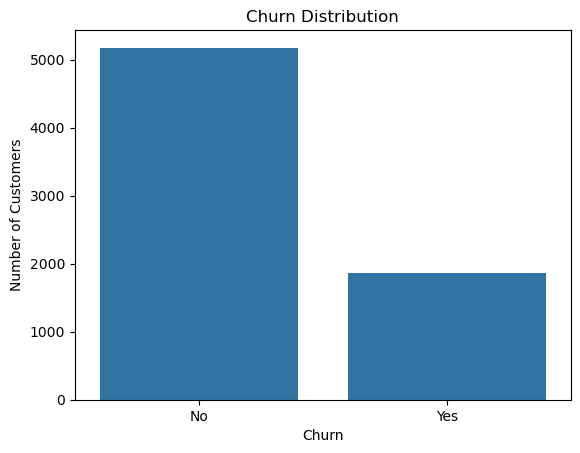

In [41]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

<div dir="rtl" style="text-align: right;">

אם רוב הלקוחות הם No, אז מודל שיחזה תמיד No יכול לקבל Accuracy יחסית גבוהה, אבל הוא לא באמת יעזור לחברה לזהות לקוחות שעומדים לעזוב.

<div dir="rtl" style="text-align: right;">

זיהוי עמודות מספריות וקטגוריאליות

In [42]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


/var/folders/33/sb_ltrs951lfcly0n7kd12qw0000gn/T/ipykernel_4293/615588880.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


<div dir="rtl" style="text-align: right;">

בדיקת התפלגות של עמודות מספריות

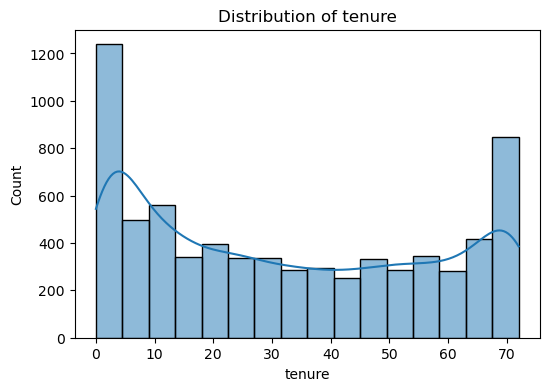

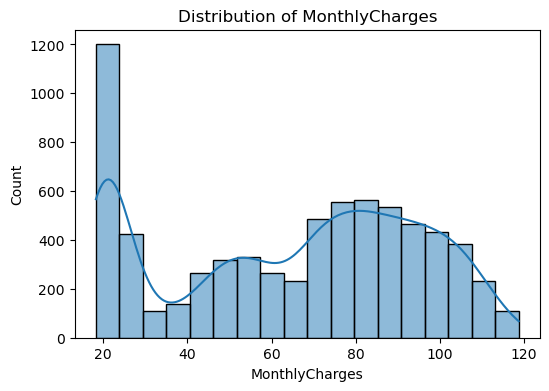

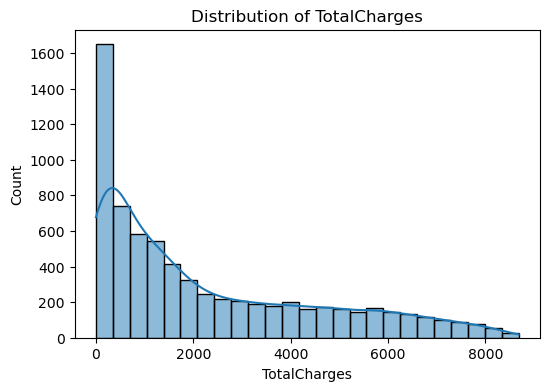

In [43]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

<div dir="rtl" style="text-align: right;">


| Feature        | מה הוא אומר                        |
| -------------- | ----------------------------------  |
| tenure         | כמה חודשים הלקוח נמצא בחברה        |
| MonthlyCharges | כמה הלקוח משלם בכל חודש            |
| TotalCharges   | כמה הלקוח שילם בסך הכול לאורך הזמן |


<div dir="rtl" style="text-align: right;">

בדיקת קשר ראשוני בין Churn למשתנים מספריים


- האם לקוחות עם tenure נמוך נוטים יותר לנטוש?
- האם לקוחות עם MonthlyCharges גבוהים נוטים יותר לנטוש?

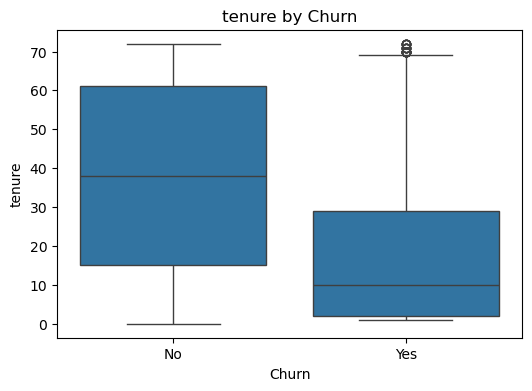

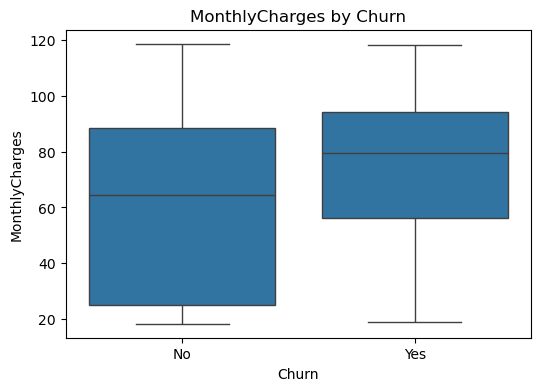

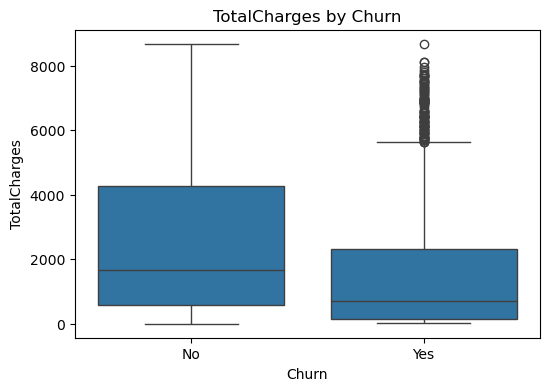

In [44]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

<div dir="rtl" style="text-align: right;">

בדיקת משתנים קטגוריאליים מרכזיים

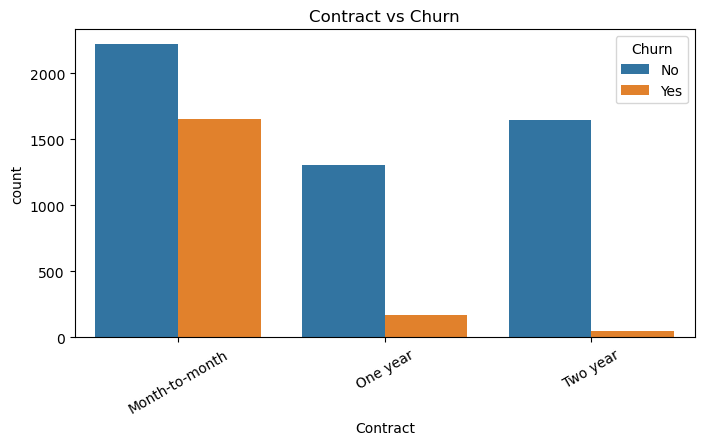

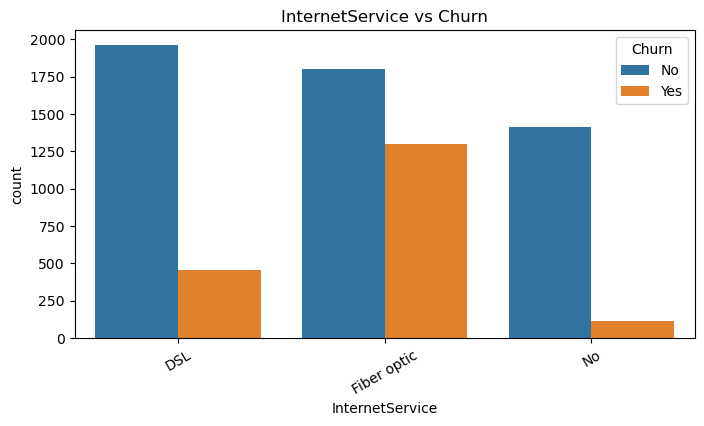

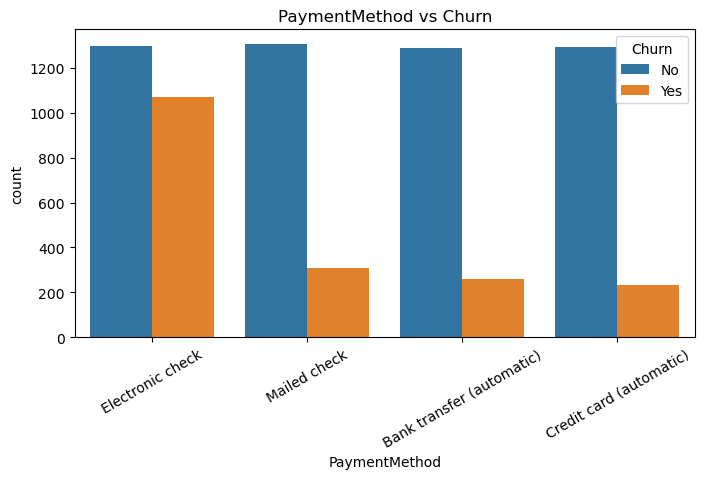

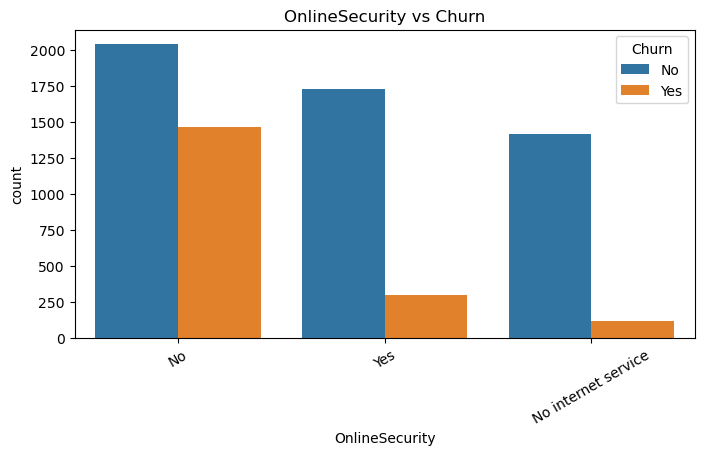

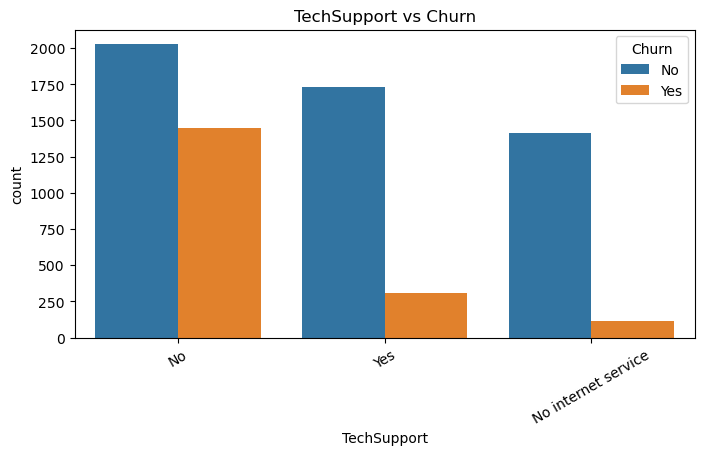

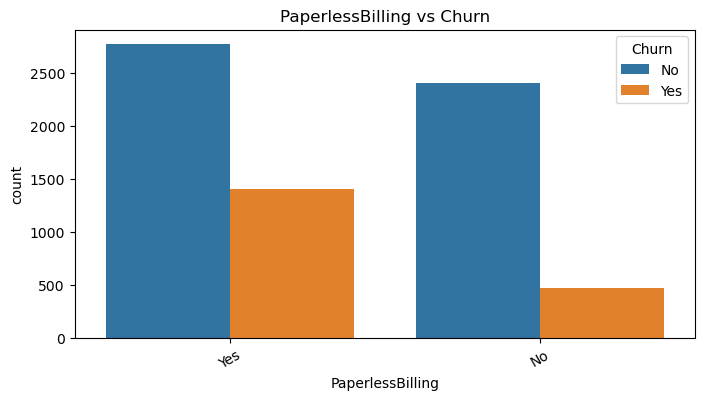

In [45]:
important_categorical = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling"
]

for col in important_categorical:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.show()

# step 2 - data preparation

<div dir="rtl" style="text-align: right;">
שלב הכנת הנתונים למודלים

- הגדרת x y
- חלוקה לסט אימון וסט מבחן
- לעשות הכנה של ה data

<div dir="rtl" style="text-align: right;">
יצירת עותק לדאטה

In [50]:
df_model = df.copy()

<div dir="rtl" style="text-align: right;">
המרת churn ל 0/1

In [51]:
df_model["Churn"]= df_model["Churn"].map({"Yes": 1, "No": 0})
df_model["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

<div dir="rtl" style="text-align: right;">
הגדרת x y

- customerID זו עמודת מזהה ולכן לא נשתמש בה כ feature
- churn זה מה שאנחנו רוצים לחזות ולכן זה יהיה y

In [52]:
x = df_model.drop(["customerID", "Churn"], axis=1)
y = df_model["Churn"]

train/ test split
<div dir="rtl" style="text-align: right;">
משתמשים ב stratify=y כי יש לנו חוסר איזון במחלקות 

- 73 אחוז לא
- 27 אחוז כן 

אנחנו רוצים שגם באימון וגם במבחן היחס בין 0 ו 1 ישמר בערך אותו דבר

In [54]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)



In [55]:
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

print("Training set class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Test set class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (5634, 19)
Test set shape: (1409, 19)
Training set class distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64
Test set class distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


<div dir="rtl" style="text-align: right;">
זיהוי עמודות מספריות וקטגוריאליות על x_train

In [57]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_features = ["SeniorCitizen"]

Categorical_features =  x_train.select_dtypes(include=["object"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Binary features:", binary_features)
print("Categorical features:", Categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary features: ['SeniorCitizen']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/33/sb_ltrs951lfcly0n7kd12qw0000gn/T/ipykernel_4293/1383387896.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_features =  x_train.select_dtypes(include=["object"]).columns.tolist()


<div dir="rtl" style="text-align: right;">
יצירת preprocessor
מגדירים:

- מילוי ערכים חסרים לעמודות מספריות: standardScaler
- מילוי ערכים חסרים לעמודות קטגוריאליות: OneHotEncoder
- עמודה בינארית משאירים כמו שהיא

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

<div dir="rtl" style="text-align: right;">

- אם יש ערכים חסרים בעמודות מספריות הוא ימלא אותם באמצעות החציון
- scale משנה את קנה המידה של המספרים ומביא את העמודות לסקאלה דומה

In [62]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


<div dir="rtl" style="text-align: right;">

- אם יש ערך חסר בעמודה קטגוריאלית הוא ימלא אותו בערך הכי נפוץ
- מודל ml לא יודע לעבוד עם טקסט. לכן צריך להפוך את הטקסט לעמודות מספריות 
- ב onehotencoder בעצם כל עמודה קטגוריאלית מתחלקת לכמות עמודות בהתאם לכמות הקטגוריות ועבור כל עמודה יהיה כתוב 0 או 1 בהתאם להאם אותו פרמטר הוא הנבחר או לא
- ignor אומר שאם במבחן מופיע קטגוריה שלא הופיעה באימון אל תקריס את הקוד- תתעלם 

In [63]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

<div dir="rtl" style="text-align: right;">
חיבור כל ההכנות יחד. 




In [64]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, Categorical_features),
    ("binary", "passthrough", binary_features)

])

<div dir="rtl" style="text-align: right;">
בדיקה שה preprocessor עובד

In [65]:
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

print("Preprocessed training set shape:", x_train_preprocessed.shape)
print("Preprocessed test set shape:", x_test_preprocessed.shape)

Preprocessed training set shape: (5634, 45)
Preprocessed test set shape: (1409, 45)


In [66]:
print("\nTrain shape before preprocessing:", x_train.shape)
print("Test shape before preprocessing:", x_test.shape)

print("\nTrain shape after preprocessing:", x_train_preprocessed.shape)
print("Test shape after preprocessing:", x_test_preprocessed.shape)

print("\ny_train distribution after preprocessing:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test distribution after preprocessing:")
print(y_test.value_counts(normalize=True) * 100)


Train shape before preprocessing: (5634, 19)
Test shape before preprocessing: (1409, 19)

Train shape after preprocessing: (5634, 45)
Test shape after preprocessing: (1409, 45)

y_train distribution after preprocessing:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

y_test distribution after preprocessing:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


# Step 3- Baseline Models

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

## logistic regrassion

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

<div dir="rtl" style="text-align: right;">
בניית צינור עבודה

- שלב 1- preprocessor
- שלב 2- logistic regression

המודל לא מקבל את הדאטה ישירות. קודם כל הנתונים עוברים תהליך של:
1. מילוי ערכים חסרים 
2. scaling לעמודות מספריות 
3. one hot encoding לעמודות קטגוריאליות

- תן למודל עד 1000 איטרציות כדי למצוא פתרון טוב: max_iter=1000 
- random state נועד לשמור על שחזור תוצאות ויציבות תוצאות . זהל א משנה אבל איזה מספר כותבים שם

In [70]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

<div dir="rtl" style="text-align: right;">
אימון המודל- השלב בו המודל לומד מהנתונים

In [71]:
log_reg_pipeline.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

<div dir="rtl" style="text-align: right;">
חיזוי על train ועל test

כאן אנחנו מבקשים מהמודל לחזות:

- 0 = לא נטש
- 1 = נטש

In [75]:
y_train_pred_log = log_reg_pipeline.predict(x_train)
y_test_pred_log = log_reg_pipeline.predict(x_test)

print("Logistic Regression - Training Classification Report:")
print(classification_report(y_train, y_train_pred_log))

print("Logistic Regression - Test Classification Report:")
print(classification_report(y_test, y_test_pred_log))

Logistic Regression - Training Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4139
           1       0.66      0.55      0.60      1495

    accuracy                           0.81      5634
   macro avg       0.75      0.72      0.74      5634
weighted avg       0.80      0.81      0.80      5634

Logistic Regression - Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



<div dir="rtl" style="text-align: right;">

הסתברות ל־Churn

זה נותן לנו הסתברות שהלקוח שייך למחלקה 1, כלומר:

הסתברות שהלקוח ינטוש

צריך את זה בשביל לחשב ROC-AUC

In [76]:
y_test_proba_log = log_reg_pipeline.predict_proba(x_test)[:, 1]

print("Logistic Regression - Test ROC AUC Score:", roc_auc_score(y_test, y_test_proba_log))


Logistic Regression - Test ROC AUC Score: 0.8419566509080574


<div dir="rtl" style="text-align: right;">

הערכת המודל


In [77]:
log_reg_results = {
    "Model": "Logistic Regression",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_log),
    "Test Accuracy": accuracy_score(y_test, y_test_pred_log),
    "Precision": precision_score(y_test, y_test_pred_log),
    "Recall": recall_score(y_test, y_test_pred_log),
    "F1 Score": f1_score(y_test, y_test_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_log)
}

log_reg_results

{'Model': 'Logistic Regression',
 'Train Accuracy': 0.8059992900248492,
 'Test Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1 Score': 0.6040462427745664,
 'ROC-AUC': 0.8419566509080574}

<div dir="rtl" style="text-align: right;">

לראות דוח מפורט


In [78]:
print(classification_report(y_test, y_test_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



<div dir="rtl" style="text-align: right;">

לראות Confusion Matrix


TN = לקוחות שלא נטשו והמודל צדק

FP = לקוחות שלא נטשו אבל המודל חשב שינטשו

FN = לקוחות שנטשו אבל המודל פספס

TP = לקוחות שנטשו והמודל צדק

בבעיית Churn חשוב לשים לב במיוחד ל־FN.

למה?
כי אלה לקוחות שבאמת נטשו, אבל המודל לא זיהה אותם. מבחינה עסקית אלה לקוחות שיכולנו לנסות לשמר, אבל פספסנו.


In [79]:
confusion_matrix(y_test, y_test_pred_log)

array([[926, 109],
       [165, 209]])